# Part 4i — Stress Period Projection: BOJ Shock Week on the Calm Manifold

**Setup:** The ISOMAP from Parts 4f–4h was trained on October 2023 NVDA data — a calm, low-volatility month. Here we ask what happens when we project the August 5–9 2024 BOJ shock week onto that same manifold.

**The event:** On August 5 2024, the Bank of Japan unexpectedly raised rates, triggering a global risk-off sell-off. NVDA fell from ~$110 to ~$92 intraday (−16%). VIX hit ~65 at the open — the highest since the COVID crash. By August 9 the stock had partially recovered to ~$104.

**The question:** Do the stress-period LOB states land inside the calm manifold, or do they escape to some new region?

In [1]:
from IPython.display import Image, display

---
## Where Do Stress Bars Land on the Calm Manifold?

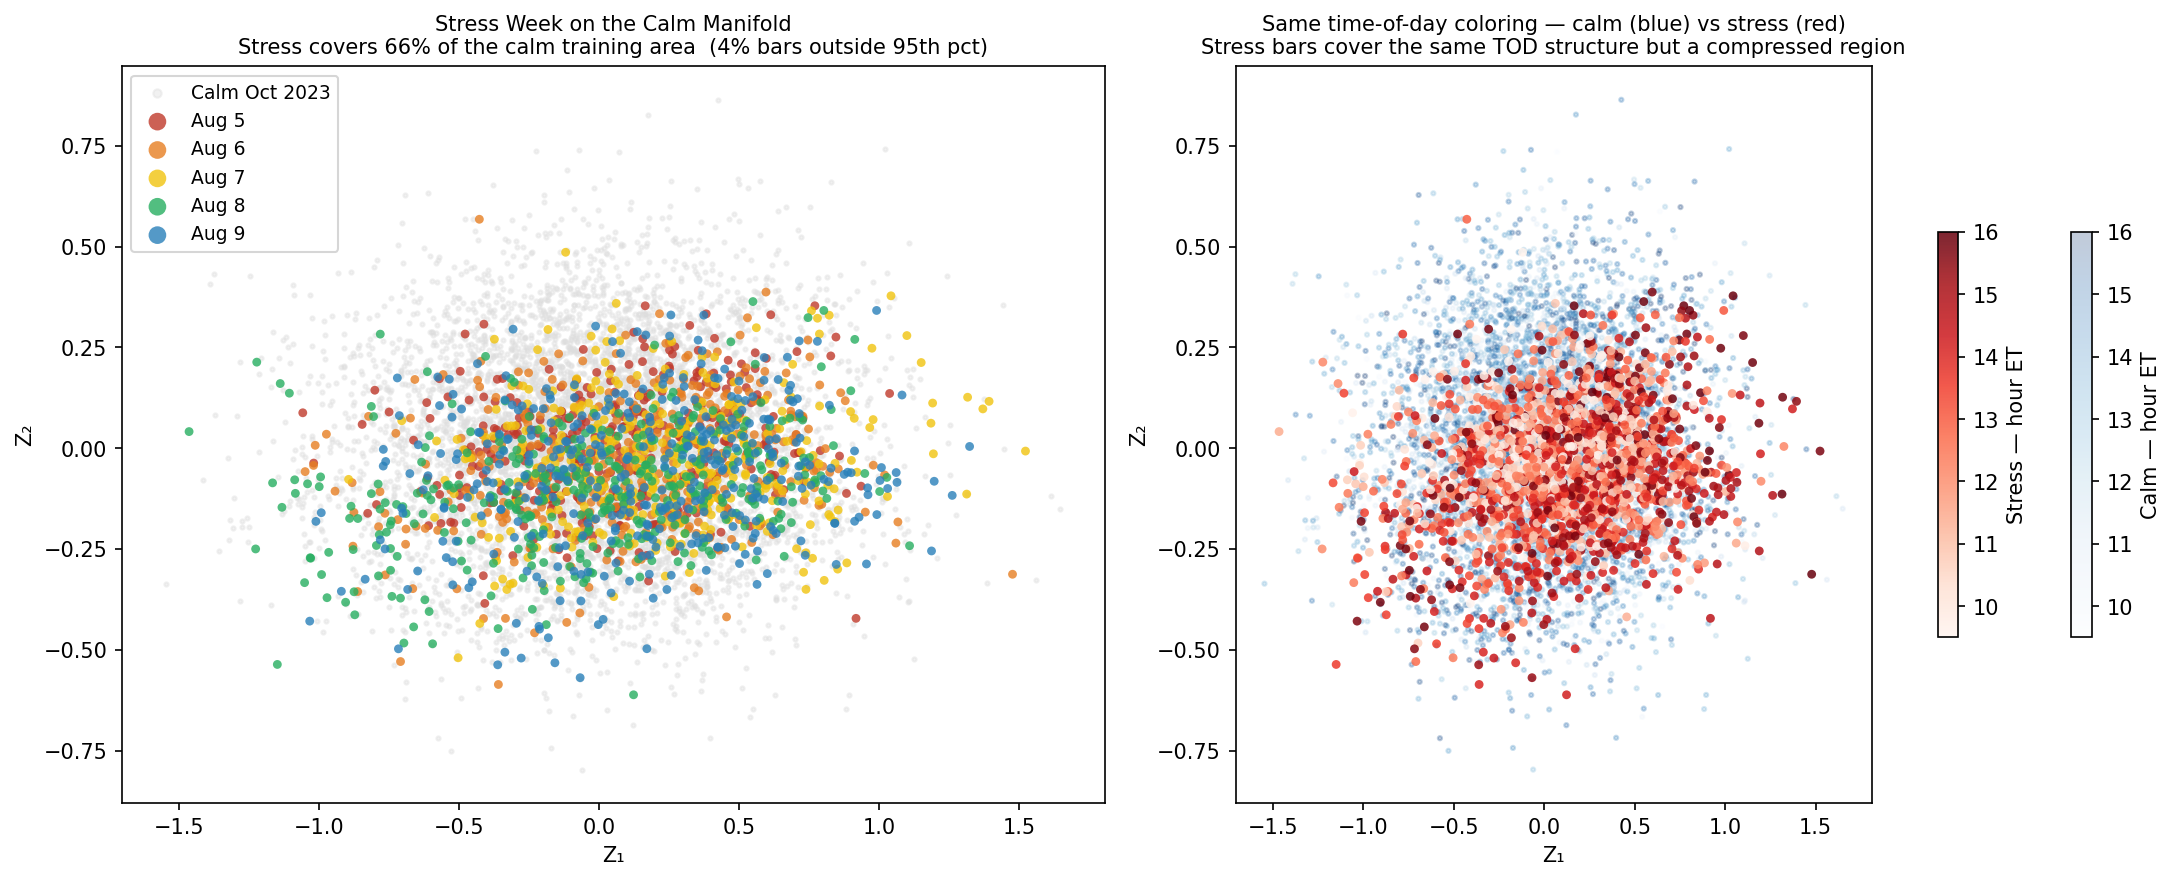

In [2]:
display(Image('figures/4i_stress_embedding.png'))

**Left panel:** Stress bars (colored by day) plotted on top of the calm training cloud (grey). They fall inside the calm region — only 3.6% of stress bars are outside the calm 95th percentile. The shock week does not push the book into some previously unseen configuration.

**Right panel:** Same embedding, both periods colored by time of day. The stress bars (red tones) sit in the same time-of-day positions as calm bars (blue tones) — Aug 5 opens look like Oct opens, Aug 5 mid-days look like Oct mid-days. The crisis doesn't reorganise the intraday structure of the order book.

There is one clear geometric difference: **stress bars cover only 66% of the area that the calm training set covers**. The book spends less time in the outlier regions of the manifold — during a directional move, the LOB is more consistently in a narrower range of states rather than exploring the full configuration space.

**Aug 5 (red) is the most concentrated near the manifold centre** — the crash day has the most consistent book state. Later recovery days (Aug 8–9, green/blue) are more spread out, as bulls and bears fight for direction and the book cycles through more varied configurations.

---
## Aug 5 2024 — Minute-by-Minute Trajectory

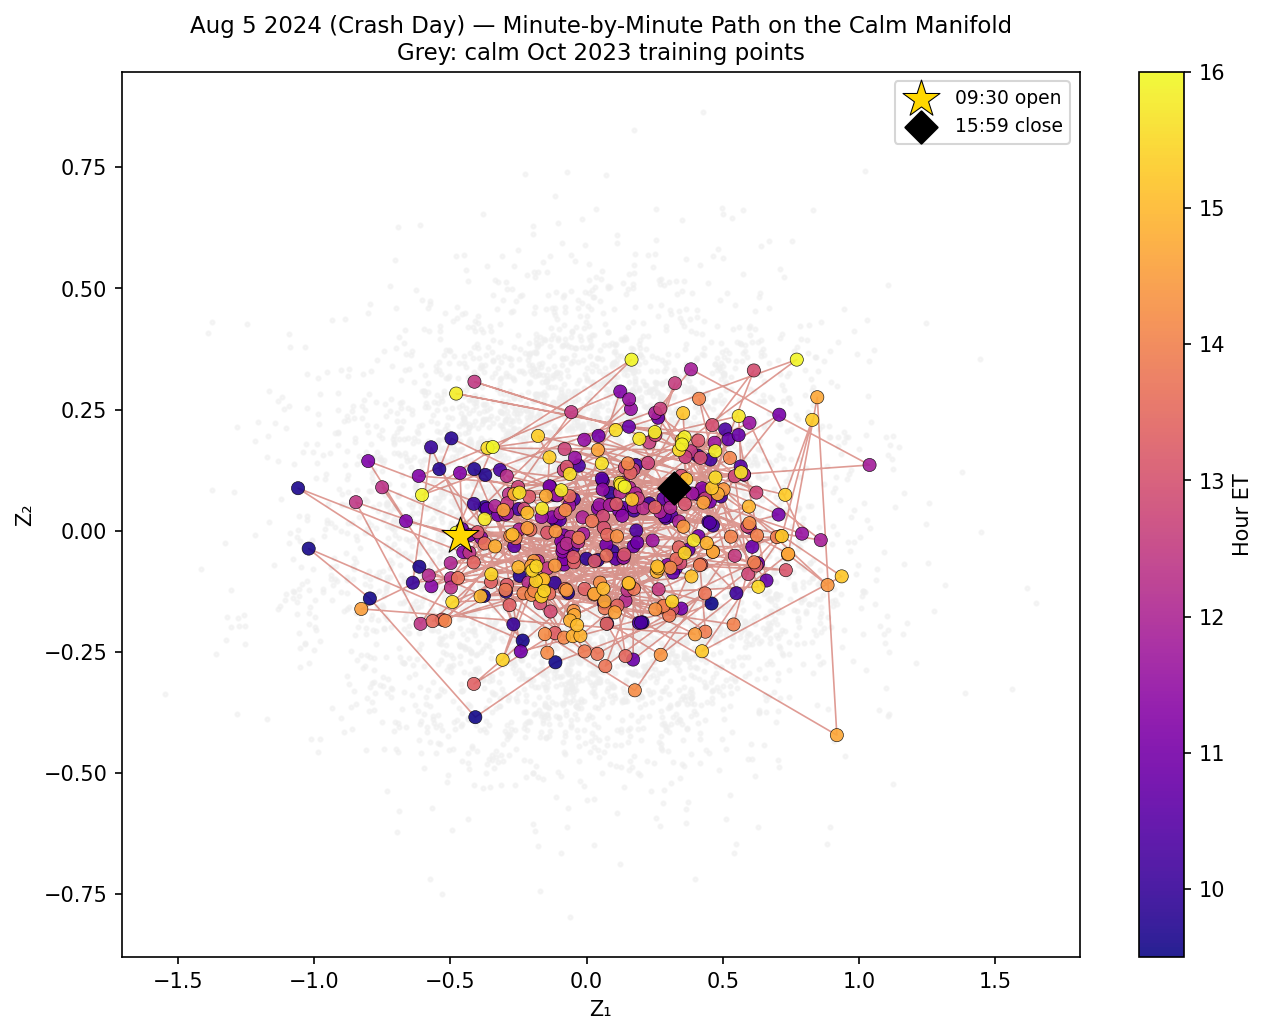

In [3]:
display(Image('figures/4i_aug5_path.png'))

The connected path traces NVDA's order book through the calm manifold over the full Aug 5 trading day. The star marks the 09:30 open; the diamond marks the 15:59 close.

The path is contained within the grey calm cloud — the book visits states that were all present during October 2023. What is unusual is the *path through those states*: the trajectory is less meandering than a calm day, more directed. The book moves from the open cluster, sweeps through the manifold, and arrives at the close in a different position than a typical calm-day trajectory would.

This is the core finding: **the LOB manifold captures the state space of the order book, not the dynamics**. Stress changes how fast and in what direction the book moves through the manifold, not which states are available.

---
## What Actually Changes: Volatility, Not State

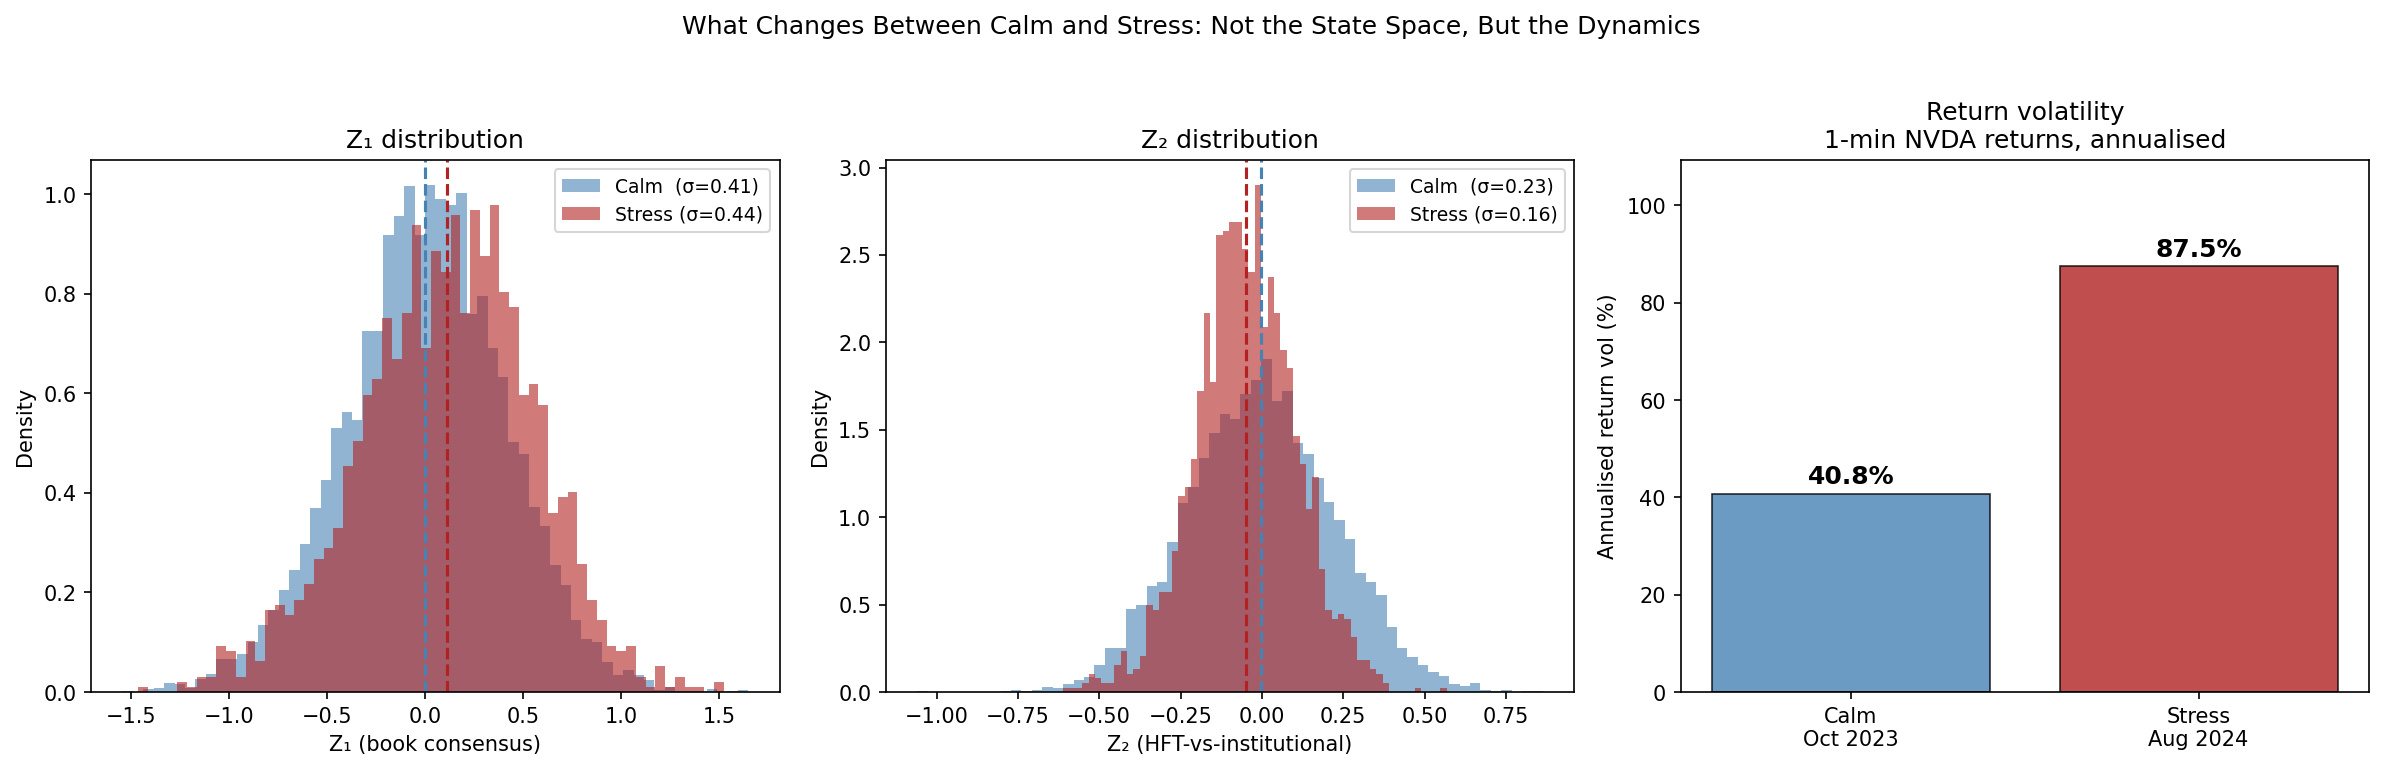

In [4]:
display(Image('figures/4i_calm_vs_stress.png'))

The Z₁ and Z₂ distributions (left, centre) barely shift between calm and stress — the mean and spread of the embedding coordinates are almost identical. The book visits the same positions on the manifold in roughly the same proportions.

The right panel shows what does change: annualised return volatility more than doubles, from **40.8% in October 2023 to 87.5% in August 2024**. The same book state — the same (Z₁, Z₂) coordinate — produces returns twice as large in magnitude during the shock week.

The implication for any LOB-based signal: a strategy calibrated on calm data will underestimate position risk in stress. The feature representation (Z₁, Z₂) is stable and transfers across regimes; the return distribution conditional on those features does not.

---
## Manifold Distance Over the Shock Week

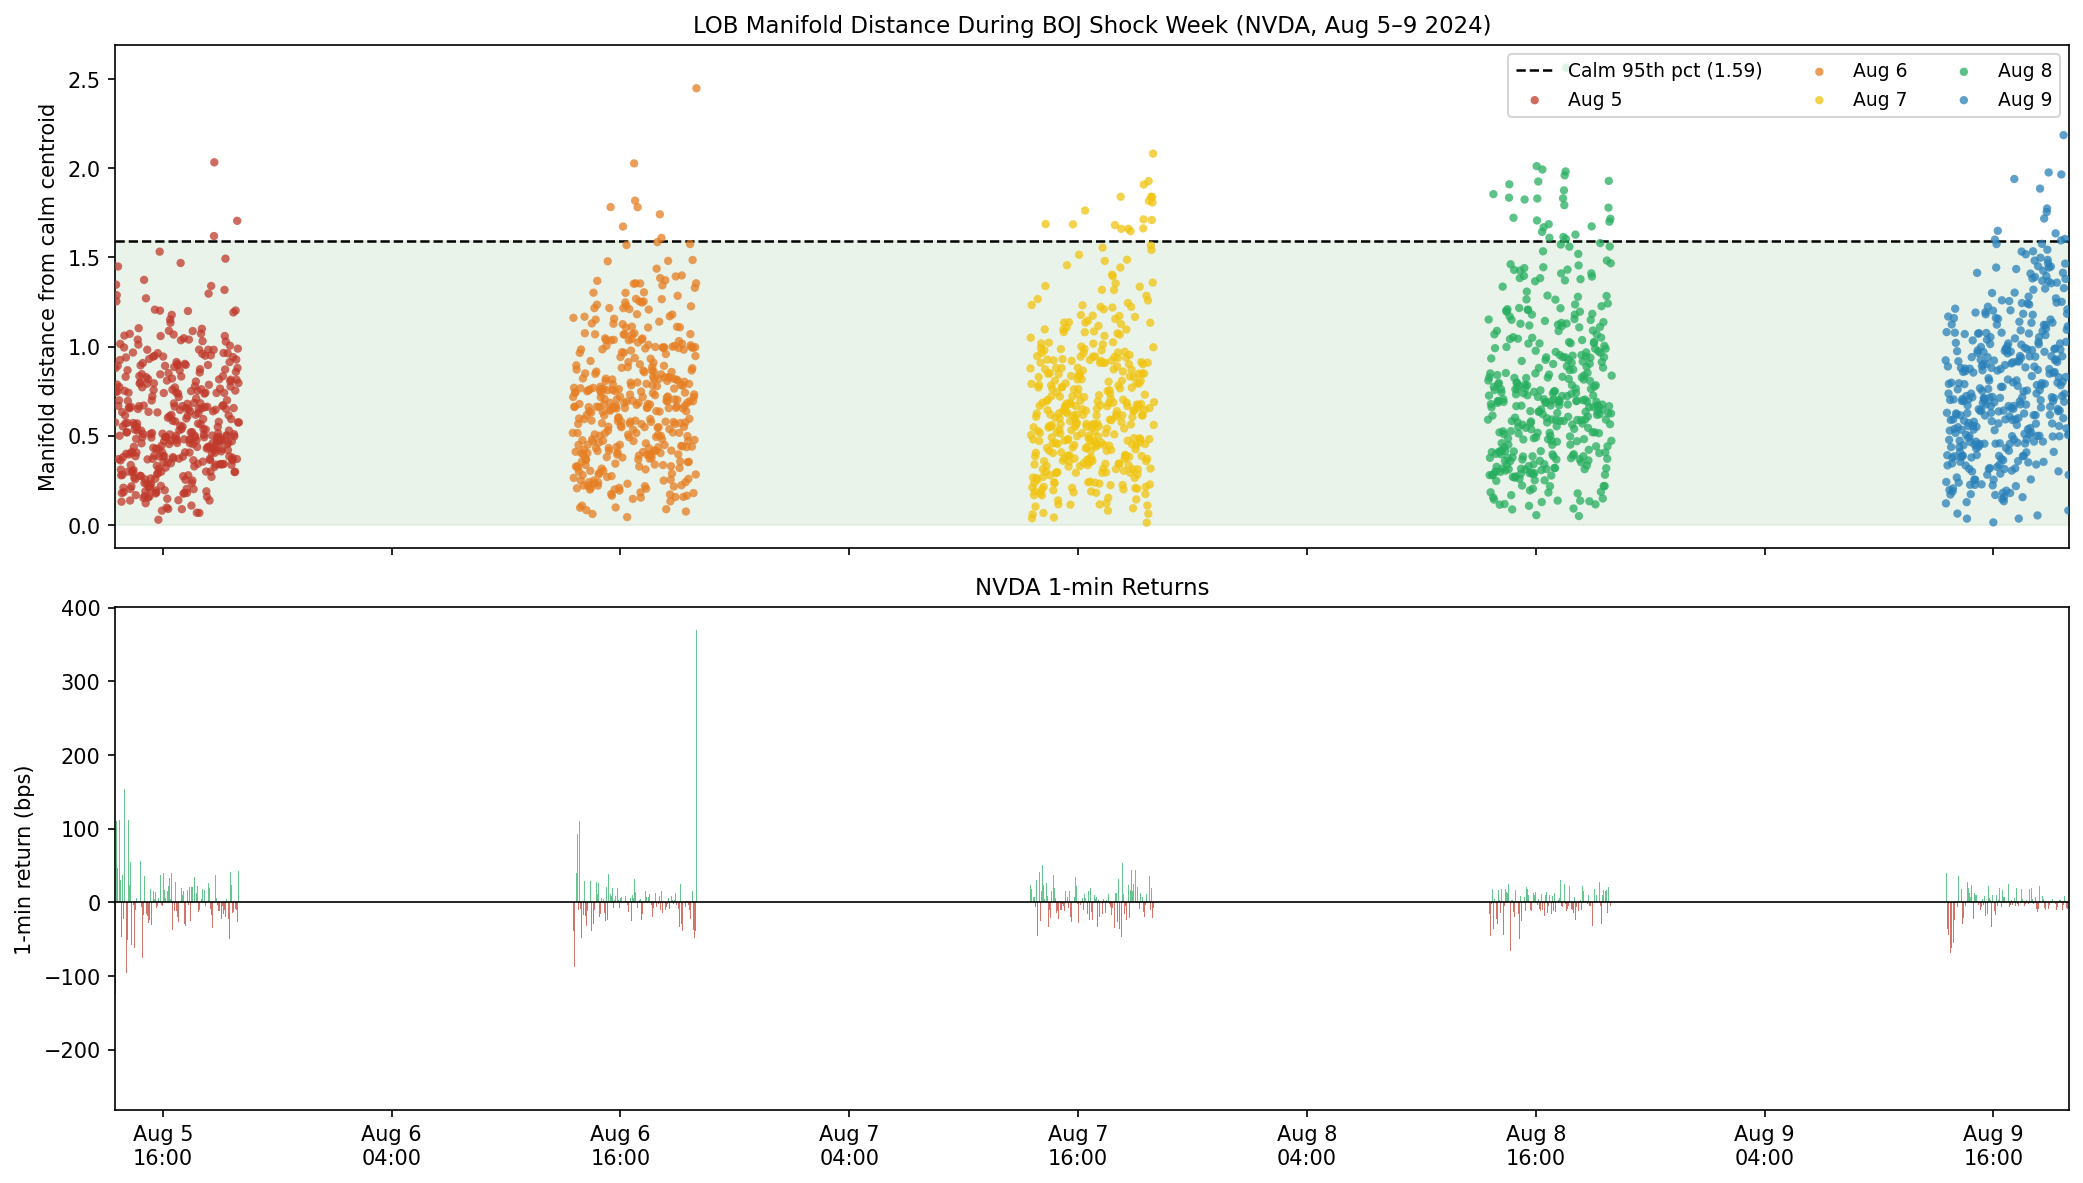

In [5]:
display(Image('figures/4i_manifold_distance.png'))

The top panel shows the manifold distance from the calm centroid for each stress-period minute. The dashed line is the calm 95th percentile — a simple threshold for "unusual" book state.

**Aug 5 (red) sits closest to the calm centroid** — the crash day has the most normal-looking book in terms of OBI means. The 1-minute OBI mean averages out the sell pressure: with every update in a minute pointing the same direction, the bar is stable and unremarkable. It is the *pace* of change, not the level, that signals stress.

**Aug 8–9 (green/blue) drift higher**, as the book cycles more erratically during the partial recovery. More unusual book states appear as market participants disagree on direction.

The return panel below confirms: Aug 5 has the largest return swings, but they are not flagged by the manifold distance. Distance from the calm centroid is not a reliable early-warning indicator for extreme returns when computed on 1-minute OBI means.

---
## Per-Day Summary

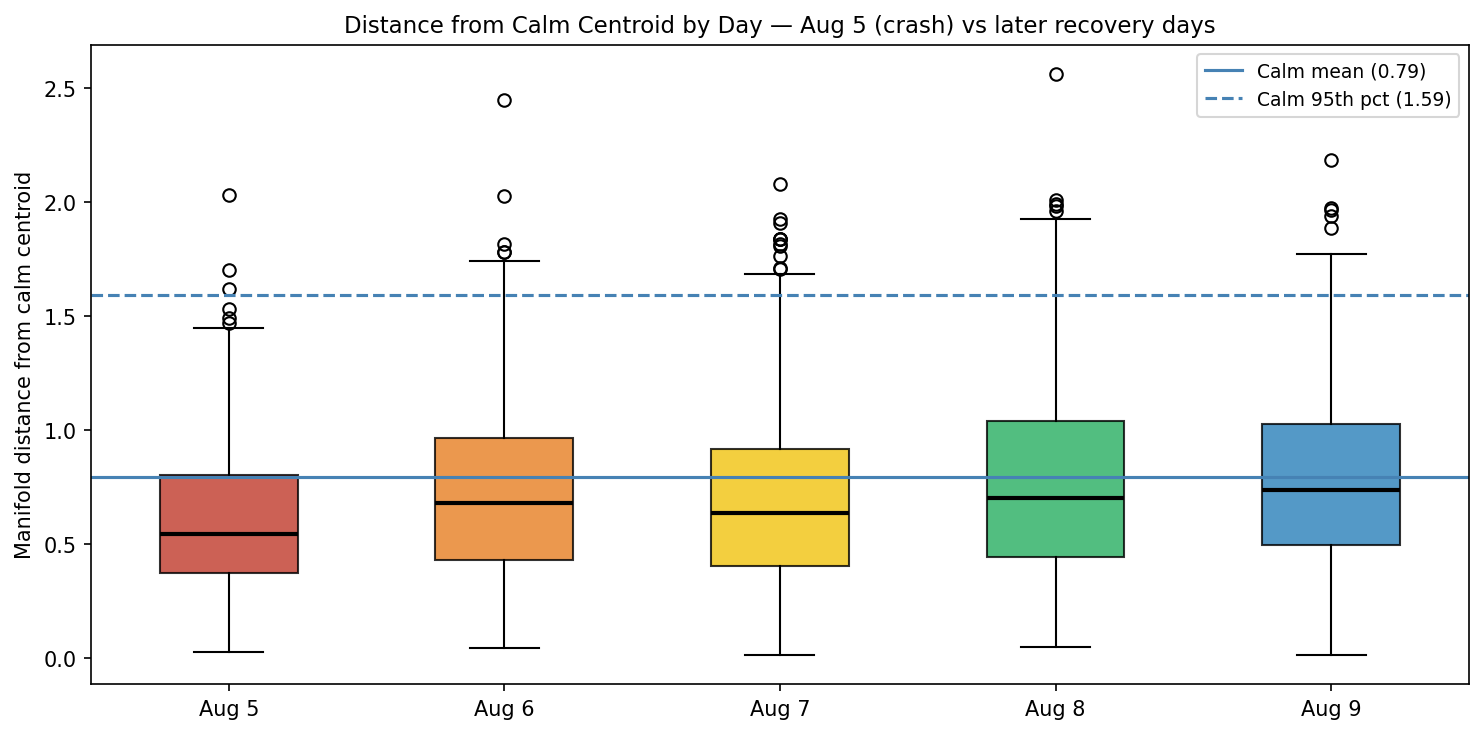

In [6]:
display(Image('figures/4i_daily_distance.png'))

The boxplots show the per-day distribution of manifold distance. Aug 5 (red, crash day) has the *lowest* median and the narrowest spread — the most concentrated book states of the week. As the week progresses and the market tries to find a new equilibrium, the book explores more varied configurations and the distance distribution widens.

| Date | Event | Mean dist | Bars above 95th pct |
|------|--------|-----------|--------------------|
| Aug 5 | Crash day (−16% intraday) | 0.605 | 3 / 390 (0.8%) |
| Aug 6 | Partial bounce | 0.716 | 8 / 390 (2.1%) |
| Aug 7 | Continued recovery | 0.700 | 18 / 390 (4.6%) |
| Aug 8 | Recovery stalls | 0.789 | 28 / 390 (7.2%) |
| Aug 9 | Range-bound | 0.791 | 13 / 389 (3.3%) |
| **Calm baseline** | **Oct 2023** | **0.793** | **5% by construction** |

---
## Summary

| Metric | Calm (Oct 2023) | Stress (Aug 5–9 2024) |
|--------|----------------|-----------------------|
| ISOMAP 2D quality | 97.2% preserved | — (calm model) |
| Manifold area covered | 3.89 (baseline) | 2.57 (66% of calm) |
| Bars outside calm 95th pct | 5% (by construction) | 3.6% |
| Z₁ mean | −0.02 | +0.02 (slightly bullish deep book) |
| Z₂ mean | −0.01 | +0.01 |
| Return vol (annualised) | 40.8% | 87.5% |

The result cuts both ways. On one hand, the calm manifold **generalises** to a genuine stress period — the LOB states during the BOJ shock are all represented in the calm training set, and the manifold coordinates are stable. On the other hand, the manifold alone is **not sufficient** to detect stress or adjust for it: the state looks normal, but the consequences of being in that state are far more severe.

This points to a natural extension: augment the manifold coordinates with realised volatility measures (intra-minute OBI variance, spread dynamics, book depth) to build a representation that is sensitive to both the static LOB state and the current market regime.